Ví dụ 1:
Cách 1:

In [11]:
# generate data
# list of points 
import numpy as np 
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(21)
from matplotlib.backends.backend_pdf import PdfPages

means = [[2, 2], [4, 1]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X1[-1, :] = [2.7, 2]
X = np.concatenate((X0.T, X1.T), axis = 1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)

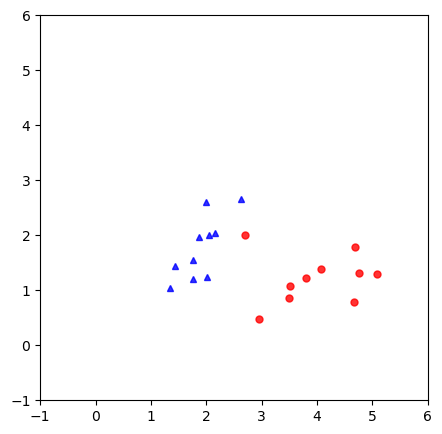

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))  

ani = plt.cla()
#plot points
ani = plt.plot(X0.T[0, :], X0.T[1, :], 'b^', markersize = 5, alpha = .8)
ani = plt.plot(X1.T[0, :], X1.T[1, :], 'ro', markersize = 5, alpha = .8)
ani = plt.axis([-1 , 6, -1, 6])
plt.show()

In [13]:
from cvxopt import matrix, solvers
C = 100
# build K
V = np.concatenate((X0.T, -X1.T), axis = 1)
K = matrix(V.T.dot(V))

p = matrix(-np.ones((2*N, 1)))
# build A, b, G, h 
G = matrix(np.vstack((-np.eye(2*N), np.eye(2*N))))

h = matrix(np.vstack((np.zeros((2*N, 1)), C*np.ones((2*N, 1)))))
A = matrix(y.reshape((-1, 2*N))) 
b = matrix(np.zeros((1, 1))) 
solvers.options['show_progress'] = False
sol = solvers.qp(K, p, G, h, A, b)

l = np.array(sol['x'])
print('lambda = \n', l.T)

lambda = 
 [[1.26997770e-08 7.29907090e-09 6.75263620e+00 1.20067067e-08
  8.83482181e-09 1.00135373e-08 9.49241066e-09 1.10095260e-08
  1.09448265e-08 1.15277180e+01 3.06483278e-09 2.92217775e-09
  3.52341246e-09 5.49363383e-09 4.48478627e-09 7.55953464e-09
  2.73325320e-09 5.71296652e-09 5.02756847e-09 1.82803543e+01]]


In [14]:
S = np.where(l > 1e-5)[0] # support set 
S2 = np.where(l < .999*C)[0] 

M = [val for val in S if val in S2] # intersection of two lists

XT = X.T # we need each column to be one data point in this alg
VS = V[:, S]
lS = l[S]
yM = y[0, M]
XM = XT[M, :]

w_dual = VS.dot(lS).reshape(-1, 1)
b_dual = np.mean(yM.T - w_dual.T.dot(XM.T))
print(w_dual.T, b_dual) 


[[-5.54276837  2.41628387]] 9.132906850859596


Cách 2:

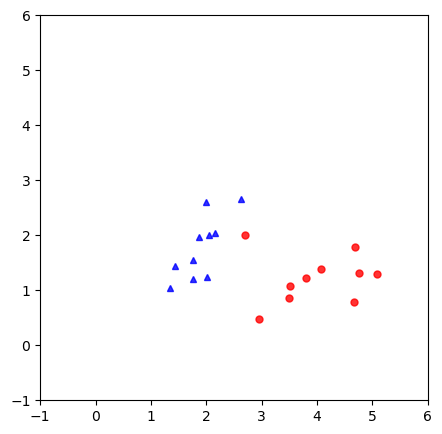

Gradient different: 0.000000
iter 1 cost: 87.184655
iter 10001 cost: 1.430915
iter 20001 cost: 1.092201
iter 30001 cost: 0.779892
iter 40001 cost: 0.491327
iter 50001 cost: 0.218693
iter 60001 cost: 0.183223
iter 70001 cost: 0.183222
iter 80001 cost: 0.183221
iter 90001 cost: 0.183220
Accuracy = 1.0
[[-5.54923267  2.41881653]] [9.14508377]


In [15]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import math
np.random.seed(21)
from matplotlib.backends.backend_pdf import PdfPages

means = [[2, 2], [4, 1]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X1[-1, :] = [2.7, 2]
X = np.concatenate((X0.T, X1.T), axis = 1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis = 1)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))  

ani = plt.cla()
#plot points
ani = plt.plot(X0.T[0, :], X0.T[1, :], 'b^', markersize = 5, alpha = .8)
ani = plt.plot(X1.T[0, :], X1.T[1, :], 'ro', markersize = 5, alpha = .8)
ani = plt.axis([-1 , 6, -1, 6])
plt.show()
C = 100
X0_bar = np.vstack((X0.T, np.ones((1, N)))) # extended data
X1_bar = np.vstack((X1.T, np.ones((1, N)))) # extended data 

Z = np.hstack((X0_bar, - X1_bar)) # as in (22)
lam = 1./C

def cost(w):
    u = w.T.dot(Z) # as in (23)
    return (np.sum(np.maximum(0, 1 - u)) + \
        .5*lam*np.sum(w*w)) - .5*lam*w[-1]*w[-1] # no bias 

def grad(w):
    u = w.T.dot(Z) # as in (23)
    H = np.where(u < 1)[1]
    ZS = Z[:, H]
    g = (-np.sum(ZS, axis = 1, keepdims = True) + lam*w)
    g[-1] -= lam*w[-1] # no weight decay on bias
    return g

eps = 1e-6
def num_grad(w):
    g = np.zeros_like(w)
    for i in range(len(w)):
        wp = w.copy()
        wm = w.copy()
        wp[i] += eps 
        wm[i] -= eps 
        g[i] = (cost(wp) - cost(wm))/(2*eps)
    return g 

w0 = np.random.randn(X0_bar.shape[0], 1) 
g1 = grad(w0)
g2 = num_grad(w0)
diff = np.linalg.norm(g1 - g2)
print('Gradient different: %f' %diff)
def grad_descent(w0, eta):
    w = w0
    it = 0 
    while it < 100000:
        it = it + 1
        g = grad(w)
        w -= eta*g
        if (it % 10000) == 1:
            print('iter %d' %it + ' cost: %f' %cost(w))
        if np.linalg.norm(g) < 1e-5:
            break 
    return w 
w0 = np.random.randn(X0_bar.shape[0], 1) 
w = grad_descent(w0, 0.001)
w_hinge = w[:-1].reshape(-1, 1)
b_hinge = w[-1]
y_pred = b_hinge + np.dot(w_hinge.T, X)
y_pred = [i/abs(i) for i in y_pred]
from sklearn.metrics import accuracy_score, confusion_matrix
print('Accuracy =', accuracy_score(y, y_pred))
print(w_hinge.T, b_hinge)

Cách 3:

In [16]:
from sklearn.svm import SVC
# Copy and put code for generate data here
y1 = y.reshape((2*N,))
X1 = X.T # each sample is one row
clf = SVC(kernel = 'linear', C = 100) # use the same C
# if C is small, method will be “SoftMagin SVM”, 
# if C is large enough, method is near to hard margin
clf.fit(X1, y1) 

w = clf.coef_
w0 = clf.intercept_
y_pred = clf.predict(X.T)
print('Accuracy =', accuracy_score(y_pred,y[0]))
print('w = ', w)
print('b = ', w0)

Accuracy = 1.0
w =  [[-5.54202362  2.4156074 ]]
b =  [9.13241559]


Ví dụ 2:

In [17]:
import pandas as pd

# Đọc dữ liệu từ tệp csv
df = pd.read_csv('D:\Code\Python\MachineLearning\Week_10\sonar.all-data.csv', header=None)

# Chuyển nhãn "M" thành 1 và nhãn "R" thành -1
df[60] = df[60].apply(lambda x: 1 if x=='M' else -1)

# Tách dữ liệu thành features (X) và labels (y)
X = df.iloc[:, :60]
y = df.iloc[:, 60]

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Tách dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng mô hình SVM với soft margin
clf = svm.SVC(kernel='linear', C=1)

# Huấn luyện mô hình trên tập huấn luyện
clf.fit(X_train, y_train)

# Dự đoán nhãn trên tập kiểm tra
y_pred = clf.predict(X_test)

# Tính độ chính xác trên tập kiểm tra
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.8571428571428571


Ví dụ 3:

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Load data
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
names = []
for i in range(48):
    names.append("word_freq_" + str(i+1))
for i in ["char_freq_;", "char_freq_(", "char_freq_[", "char_freq_!", "char_freq_$", "char_freq_#"]:
    names.append(i)
names.extend(["capital_run_length_average", "capital_run_length_longest", "capital_run_length_total", "spam"])
data = pd.read_csv(url, names=names)

# Step 2: Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:, :-1], data.iloc[:, -1], test_size=0.3, random_state=42)

# Step 3: Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Train SVM model with softmargin and C option
C = 1 # choose the value of C
svm = SVC(kernel='linear', C=C)
svm.fit(X_train, y_train)

# Step 5: Predict on test data
y_pred = svm.predict(X_test)

# Step 6: Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9268645908761767
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       804
           1       0.93      0.89      0.91       577

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381

